In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

sns.set_palette("colorblind")

CI95_Z = 1.96  # normal-approximation 95% CI half-width, in units of SEM
N_TAIL_EVALS = 3  # matches compute_final_values' n_tail elsewhere in this repo

CSV_PATHS = {
    "lightsout": "lightsout-icot-final.csv",
    "slidingpuzzle": "slidingpuzzle-icot-final.csv",
    "sokoban": "sokoban-icot-final.csv",
}

FILTERS = {
    "lightsout": {
        "system.gamma": 0.999,
        "system.halting_lr": None,
    },
    "slidingpuzzle": {
        # "network.actor_network.pre_torso.halting_temperature": 1.0,
        "network.actor_network.pre_torso.stop_gradient_halting_input": False,
        "system.actor_lr": 0.0003,
        "system.halting_ent_coef": 0.0,
        "system.clip_halting_head": True,
        # "system.halting_lr": 0.0001,
    },
    "sokoban": {
        "network.actor_network.pre_torso.halting_temperature": 1.0,
        "network.actor_network.pre_torso.stop_gradient_halting_input": False,
        "system.halting_ent_coef": 0.01,
        "system.clip_halting_head": False,
    },
}


ARCH = None  # None = use whichever single arch is present in the CSV
TRIM_N = 0  # drop this many highest- and lowest-performing seeds per (budget, gamma) group before averaging
SEED_PERCENTILE = 0  # per budget, keep runs whose final training success rate is at or above this percentile; None keeps all
AGGREGATE = "iqm"  # across seeds: "iqm" / "median" (95% bootstrap CI) or "mean" (95% normal CI)
N_BOOTSTRAP = 10000

In [2]:
def get_df(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df["state"] == "finished"]
    df = df[~df["sgh"]]

    missing = [c for c in ("gamma", "absolute/episode_return/mean") if c not in df.columns]
    if missing:
        raise ValueError(
            f"{csv_path} is missing {missing} - re-fetch it with the updated fetch_wandb_lightsout_hd64.py"
        )
    df = df[df["gamma"].notna()]

    if ARCH is None:
        archs = df["arch"].unique()
        if len(archs) != 1:
            raise ValueError(f"Multiple architectures present ({list(archs)}) - set ARCH explicitly")
        ARCH = archs[0]
    df = df[df["arch"] == ARCH]

    return df

In [3]:
def budget_label(min_steps, max_steps):
    return f"uniform={min_steps}" if min_steps == max_steps else f"adaptive[{min_steps}-{max_steps}]"


[lightsout] 60 runs kept: {(1, 1): 10, (1, 5): 10, (2, 2): 10, (3, 3): 10, (4, 4): 10, (5, 5): 10}
[slidingpuzzle] 60 runs kept: {(1, 1): 10, (1, 5): 10, (2, 2): 10, (3, 3): 10, (4, 4): 10, (5, 5): 10}
[sokoban] 30 runs kept: {(1, 1): 5, (1, 5): 5, (2, 2): 5, (3, 3): 5, (4, 4): 5, (5, 5): 5}


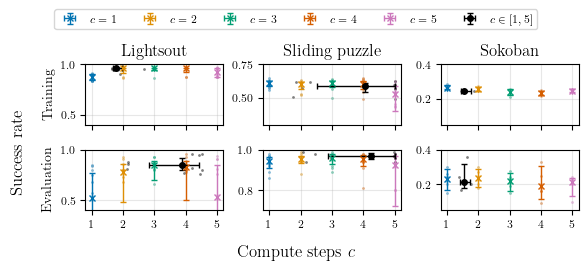

In [4]:
# Compute vs. solve rate: one point per budget (mean +- 95% CI over seeds, in both axes).
# Row 0 uses the training (actor/*) metrics averaged over each run's last N_TAIL_EVALS logs;
# row 1 uses the absolute/* metrics, a single post-training value per run.
# lightsout/slidingpuzzle reward 1 on solve and 0 otherwise, so their return is already the solve rate;
# sokoban's return includes per-step penalties, so it needs the logged solved_episode.
ROWS = {
    "Training": ("actor", {
        "lightsout": "episode_return/mean",
        "slidingpuzzle": "episode_return/mean",
        "sokoban": "solved_episode/mean",
    }),
    "Evaluation": ("absolute", {
        "lightsout": "episode_return/mean",
        "slidingpuzzle": "episode_return/mean",
        "sokoban": "solved_episode/mean",
    }),
}

# FILTERS keys are wandb config paths; the CSVs store a subset under short names.
FILTER_KEY_TO_COLUMN = {
    "system.gamma": "gamma",
    "system.ent_coef": "ent_coef",
    "network.actor_network.pre_torso.halting_temperature": "halting_temperature",
    "network.actor_network.pre_torso.stop_gradient_halting_input": "sgh",
    "system.halting_ent_coef": "halting_ent_coef",
    "system.actor_lr": "actor_lr",
    "system.clip_halting_head": "clip_halting_head",
    "system.halting_lr": "halting_lr",
}
# Only meaningful for adaptive (min_steps < max_steps) policies.
HALTING_FILTER_KEYS = {
    "network.actor_network.pre_torso.halting_temperature",
    "network.actor_network.pre_torso.stop_gradient_halting_input",
    "system.halting_ent_coef",
    "system.clip_halting_head",
    "system.halting_lr",
}

ENV_NAMES = {
    "lightsout": "Lightsout",
    "slidingpuzzle": "Sliding puzzle",
    "sokoban": "Sokoban",
}


def load_filtered(env_name):
    df = pd.read_csv(CSV_PATHS[env_name])
    df = df[df["state"] == "finished"]
    adaptive = df["min_steps"] != df["max_steps"]
    keep = pd.Series(True, index=df.index)
    for key, val in FILTERS.get(env_name, {}).items():
        col = FILTER_KEY_TO_COLUMN.get(key)
        if col is None or col not in df.columns:
            print(f"[{env_name}] filter {key!r} has no CSV column - ignored")
            continue
        if val is None:  # config unset -> NaN in the CSV
            match = df[col].isna()
        elif isinstance(val, float):
            match = np.isclose(df[col], val)
        else:
            match = df[col] == val
        keep &= (match | ~adaptive) if key in HALTING_FILTER_KEYS else match
    df = df[keep]
    if SEED_PERCENTILE is not None:
        # Score on the training metric so the evaluation row isn't used for selection.
        train_prefix, train_metrics = ROWS["Training"]
        per_run = df.sort_values("_step").groupby("run_id").agg(
            score=(f"{train_prefix}/{train_metrics[env_name]}", tail_mean),
            min_steps=("min_steps", "first"), max_steps=("max_steps", "first"),
        )
        cutoff = per_run.groupby(["min_steps", "max_steps"])["score"].transform(
            lambda s: s.quantile(SEED_PERCENTILE / 100)
        )
        df = df[df["run_id"].isin(per_run.index[per_run["score"] >= cutoff])]
    runs = df.drop_duplicates("run_id")
    print(
        f"[{env_name}] {runs['run_id'].nunique()} runs kept:",
        runs.groupby(["min_steps", "max_steps"]).size().to_dict(),
    )
    return df


def tail_mean(s):
    return s.dropna().tail(N_TAIL_EVALS).mean()


def compute_vs_solve(df, x_metric, y_metric):
    per_run = df.sort_values("_step").groupby("run_id").agg(
        x=(x_metric, tail_mean), y=(y_metric, tail_mean),
        min_steps=("min_steps", "first"), max_steps=("max_steps", "first"),
    ).dropna(subset=["x", "y"])
    rows = []
    for (mn, mx), g in per_run.groupby(["min_steps", "max_steps"]):
        x_c, x_err = center_and_ci(g["x"].values)
        y_c, y_err = center_and_ci(g["y"].values)
        rows.append({
            "budget": budget_label(mn, mx), "n": len(g),
            "x": x_c, "x_ci": x_err, "y": y_c, "y_ci": y_err,
            "xs": g["x"].values, "ys": g["y"].values,
        })
    return pd.DataFrame(rows)


def aggregate(v, axis=-1):
    """AGGREGATE of v along `axis`. "iqm" is the interquartile mean: the mean of the
    middle 50% after dropping int(n/4) values from each end (scipy.stats.trim_mean(v, 0.25))."""
    v = np.asarray(v, dtype=float)
    if AGGREGATE == "mean":
        return v.mean(axis=axis)
    if AGGREGATE == "median":
        return np.median(v, axis=axis)
    if AGGREGATE == "iqm":
        n = v.shape[axis]
        k = int(0.25 * n)
        return np.take(np.sort(v, axis=axis), np.arange(k, n - k), axis=axis).mean(axis=axis)
    raise ValueError(f"Unknown AGGREGATE {AGGREGATE!r}")


def center_and_ci(v, rng=np.random.default_rng(0)):
    """AGGREGATE of v across seeds plus a 95% CI as a [[lower], [upper]] errorbar
    offset: normal-approximation for the mean, percentile bootstrap for median/iqm."""
    n = len(v)
    if AGGREGATE == "mean":
        c = v.mean()
        h = CI95_Z * v.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        return c, [[h], [h]]
    c = aggregate(v)
    if n <= 1:
        return c, [[0.0], [0.0]]
    boot = aggregate(rng.choice(v, size=(N_BOOTSTRAP, n), replace=True), axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return c, [[c - lo], [hi - c]]


def pretty_budget(budget):
    if "uniform" in budget:
        return "$c = {}$".format(budget.split("=")[-1])
    lo, hi = budget.split("[")[1].rstrip("]").split("-")
    return "$c \\in [{}, {}]$".format(lo, hi)


env_names = list(CSV_PATHS)
nrows, ncols = len(ROWS), len(env_names)
figsize = set_size(doc_width_pt, fraction=0.95, subplots=(nrows, ncols), use_golden_ratio=True)
fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=False, squeeze=False)

# One palette across panels so a budget keeps its colour even when a panel is missing it.
colors = dict(zip([budget_label(c, c) for c in range(1, 6)], sns.color_palette("colorblind")))
legend_entries = {}
for col_i, env_name in enumerate(env_names):
    df_env = load_filtered(env_name)
    for row_i, (row_name, (prefix, y_metrics)) in enumerate(ROWS.items()):
        ax = axes[row_i, col_i]
        x_metric = f"{prefix}/compute_time/mean"
        y_metric = f"{prefix}/{y_metrics[env_name]}"
        for metric in (x_metric, y_metric):
            if metric not in df_env.columns:
                raise ValueError(f"{CSV_PATHS[env_name]} is missing {metric!r} - re-fetch it with fetch_wandb.py")
        stats = compute_vs_solve(df_env, x_metric, y_metric)
        budgets = sorted(stats["budget"], key=lambda b: (b.startswith("adaptive"), b))
        for _, row in stats.set_index("budget").loc[budgets].reset_index().iterrows():
            color = colors.get(row["budget"], (0.0, 0.0, 0.0))
            ax.scatter(row["xs"], row["ys"], color=color, s=4, alpha=0.5, linewidths=0)
            h = ax.errorbar(
                row["x"], row["y"], xerr=row["x_ci"], yerr=row["y_ci"],
                fmt="o" if row["budget"].startswith("adaptive") else "x",
                color=color, ms=4, elinewidth=1, capsize=2,
            )
            legend_entries.setdefault(pretty_budget(row["budget"]), h)
        if row_i == 0:
            ax.set_title(ENV_NAMES[env_name])
        if col_i == 0:
            ax.set_ylabel(row_name)
        ax.grid(True, alpha=0.3)
        if env_name == "slidingpuzzle":
            if row_i == 0:
                ax.set_ylim(0.3, 0.75)
            elif row_i == 1:
                ax.set_ylim(0.7, 1.0)
        elif env_name == "lightsout":
            ax.set_ylim(0.4, 1.0)
        elif env_name == "sokoban":
            ax.set_ylim(0.05, 0.4)
        ax.set_xticks([1, 2, 3, 4, 5])

fig.supylabel("Success rate")
fig.supxlabel("Compute steps $c$", y=0.06)
fig.legend(
    legend_entries.values(), legend_entries.keys(),
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0), loc="lower center",
    ncols=6, borderaxespad=0.0, frameon=True,
)
fig.tight_layout()
plt.savefig("analysis-icot-compute-vs-solve.pdf", dpi=600, format="pdf", bbox_inches="tight")
